In [100]:
from ProtMamba_ssm.utils import *
from ProtMamba_ssm.dataloaders import *
from ProtMamba_ssm.modules import *
from aux_msa_functions import *

import numpy as np
import torch
import os
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
from Bio import SeqIO, Phylo
import pandas as pd


In [101]:
GH19_MSA = read_msa("GH19_Curated_MSA.fasta")
GH19_ancestors = read_msa('GH19_Ancestors_Library.fasta')
Antifungal_chitinases = read_msa('Antifungal_Chitinases.fasta')
GH19_seqs = read_msa('GH19_plant.txt')
GH19_labelled_seqs = read_msa('GH19_labeled.txt')

In [126]:
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model("./ProtMamba-Long-foundation",
            model_class=MambaLMHeadModelwithPosids,
            device="cuda",
            dtype=torch.bfloat16,
            checkpoint_mixer=False # Must be False when using model for Inference
            )

model = model.to(device)
    
def fim(target_seq, context_seqs, selected_pos_list, original_length_list, gen_length_list, loop_numbers, autoreg = True):
    

    context_seqs = [x for x in context_seqs  if target_seq[0].replace("-","") != x[1].replace("-","")]

    context = tokenizer([seq[1] for seq in context_seqs], concatenate=True)
    target = tokenizer(target_seq, concatenate=True).to(device)
    
    original_seqs_list = []
    original_seq_tokens_list = []

    mask_dictionary = {}
    autoreg_dictionary = {}
    n_masks = len(selected_pos_list)
    
    mask_id = 1

    for i in range(len(selected_pos_list)):

        if original_length_list[i] == 0:
            continue

        original_seq_tokens = target[0][1:][selected_pos_list[i]:selected_pos_list[i] + original_length_list[i]]
        original_seqs_list.append(decode_sequence(original_seq_tokens.tolist()))
        original_seq_tokens_list.append(original_seq_tokens) 

        if loop_numbers[i] == 6:
            if autoreg:
                autoreg_dictionary["<cls>"] = selected_pos_list[i]
                continue

        mask_dictionary[f"<mask-{mask_id}>"] = ((selected_pos_list[i] + 1,selected_pos_list[i] + original_length_list[i] + 1),gen_length_list[i])

        mask_id += 1   
    
    if len(mask_dictionary) == 0 and len(autoreg_dictionary) == 0:
        return None
        
    softmax = nn.Softmax(dim=-1)

    average_orig_probs = []
    average_pred_probs = []
    median_orig_probs = []
    median_pred_probs = []
    pred_seqs = []  

    if len(mask_dictionary) != 0:       
        input_seq, targ_pos, is_fim_dict = prepare_target(target, use_fim=mask_dictionary)

        input_seq = input_seq.to(device)
        targ_pos = targ_pos.to(device)

        context_tokens, context_pos_ids = prepare_tokens(context,
                            target_tokens=input_seq,
                            target_pos_ids=targ_pos,
                            DatasetClass=Uniclust30_Dataset,
                            num_sequences=len(context_seqs),
                            fim_strategy="no-scramble",
                            mask_fraction=1,
                            max_patches=1,
                            add_position_ids="1d")  
        
        flag = 0
        count = 0

        while True:

            count += 1

            if count >= 100:
                print("why?")
                raise Exception("Tries Exceeded")

            if flag == 1:
                break

            # try:
            output = generate_sequence(model,
                        context_tokens,
                        position_ids=context_pos_ids,
                        is_fim=is_fim_dict,
                        max_length= context_tokens.shape[1] + 100,
                        temperature=1.,
                        top_k=10,
                        top_p=0.0,
                        mask_dictionary=mask_dictionary,
                        return_dict_in_generate=True,
                        output_scores=True,
                        eos_token_id=AA_TO_ID["<cls>"],
                        device="cuda")
                                
            # print(decode_sequence(input_seq[0].tolist()))
            # print(targ_pos[0].tolist())

            # print(output["generated"][0])
            # print(output["scores"][0].shape)
            
            cur_pos = 0
            generated_tokens = output["generated_tokens"][0]
            logits = torch.tensor(output["scores"][0])
            
            probabilities = softmax(logits).numpy()

            list_ind = 0
            
            for i in range(n_masks):

                if original_length_list[i] == 0:
                    pred_seqs.append("")
                    average_orig_probs.append(None)
                    average_pred_probs.append(None)
                    median_orig_probs.append(None)
                    median_pred_probs.append(None)
                    continue
                
                if loop_numbers[i] == 6:
                    if autoreg:
                        list_ind += 1
                        continue

                gen_length = gen_length_list[i]
                orig_length = original_length_list[i]

                gen_seq_tokens = generated_tokens[cur_pos + 1: cur_pos + gen_length + 1]
                
                orig_probs = []
                pred_probs = []

                
                for j,pos in enumerate(range(cur_pos + 1, cur_pos + gen_length + 1)):
                    
                    if len(pred_probs) <  gen_length:

                        pred_probs.append(probabilities[pos,generated_tokens[pos]])

                    if len(orig_probs) < gen_length:
                        
                        orig_probs.append(probabilities[pos,original_seq_tokens_list[list_ind][j]])
                
                list_ind += 1


                average_orig_probs.append(np.mean(orig_probs))
                average_pred_probs.append(np.mean(pred_probs))
                median_orig_probs.append(np.median(orig_probs))
                median_pred_probs.append(np.median(pred_probs))
                pred_seqs.append(decode_sequence(gen_seq_tokens))

                cur_pos += gen_length + 1

            flag = 1
                
            # # except:
            #     continue

    if len(autoreg_dictionary) != 0:

        input_seq, targ_pos = prepare_target(target, use_fim=autoreg_dictionary)

        while True:

            output = generate_sequence(model,
                                context,
                                position_ids=torch.tensor(list(range(context.shape[1])))[None,:],
                                is_fim=autoreg_dictionary,
                                max_length=context.shape[1] + original_length_list[-1],
                                temperature=1.,
                                top_k=10,
                                top_p=0.0,
                                return_dict_in_generate=True,
                                output_scores=True,
                                eos_token_id=torch.tensor([AA_TO_ID["<cls>"],AA_TO_ID["<mask-1>"], AA_TO_ID["<mask-2>"], AA_TO_ID["<mask-3>"],
                                                            AA_TO_ID["<mask-4>"], AA_TO_ID["<mask-5>"]]).to("cuda"),
                                device="cuda")
            
            output_seq = output["generated"][0]
            
            if "<" not in output_seq:
                break

        # print(output_seq)
            
        logits = torch.tensor(output["scores"][0])
        generated_tokens = output["generated_tokens"][0]
        probabilities = softmax(logits).numpy()
    
        orig_probs = []
        pred_probs = []

        # print(original_seqs_list[-1])

        for pos in range(len(output_seq)):
            
            pred_probs.append(probabilities[pos,generated_tokens[pos]])                
            orig_probs.append(probabilities[pos,original_seq_tokens_list[-1][pos]])
        
        average_orig_probs.append(np.mean(orig_probs))
        average_pred_probs.append(np.mean(pred_probs))
        median_orig_probs.append(np.median(orig_probs))
        median_pred_probs.append(np.median(pred_probs))
        pred_seqs.append(output_seq)

        # cur_pos += gen_length + 1

    output["average_orig_prob"] = average_orig_probs
    output["average_pred_prob"] = average_pred_probs
    output["median_orig_prob"] = median_orig_probs
    output["median_pred_prob"] = median_pred_probs
    output["pred_seqs"] = pred_seqs

    average_orig_probs = np.array(average_orig_probs)
    output["overall_average_orig_prob"] = np.mean(average_orig_probs[average_orig_probs != np.array(None)])

    average_pred_probs = np.array(average_pred_probs)
    output["overall_average_pred_prob"] = np.mean(average_pred_probs[average_pred_probs != np.array(None)])

    return output
    

Using a model that was pretrained with gradient checkpointing but now do not want to use it. Changed the keys of the state_dict to match the model's keys.


In [104]:
Antifungal_chitinase_seqs = np.array([list(x[1]) for x in Antifungal_chitinases]) 
Antifungal_chitinase_seqs = Antifungal_chitinase_seqs[:,165:-12]
Antifungal_chitinase_seqs = np.concatenate((Antifungal_chitinase_seqs[:,:96], Antifungal_chitinase_seqs[:,97:]), axis = 1)
Antifungal_chitinase_seqs = [''.join(x) for x in Antifungal_chitinase_seqs.tolist()]
    
Antifungal_chitinase_names = [x[0] for x in Antifungal_chitinases]
Antifungal_chitinases_clean = [(a,b) for a,b in zip(Antifungal_chitinase_names, Antifungal_chitinase_seqs)]
del Antifungal_chitinases_clean[9]

In [105]:
def isfloat(x):
    try:
        return float(x)
    except:
        return np.nan

anc1_table = pd.read_excel("./Tm_activity/Anc1.xlsx")
anc3_table = pd.read_excel("./Tm_activity/Anc3.xlsx")
anc5_table = pd.read_excel("./Tm_activity/Anc5.xlsx")

all_anc_table = pd.concat((anc1_table,anc3_table,anc5_table), axis = 0).reset_index(drop=True)
all_anc_table = all_anc_table.rename(columns={"sd":"activity sd","sd.1":"activity_perc_sd","sd.2":"Tm sd"})

all_anc_table["Tm"] = all_anc_table["Tm"].apply(isfloat)
all_anc_table["chitinase (lysate)"] = all_anc_table["chitinase (lysate)"].apply(isfloat)

### Contexts from catalytic domain

In [104]:
loop_contexts = pd.Series([x[0].split('_')[1] for x in GH19_labelled_seqs]).unique()

contexts_dict = {}

for context in loop_contexts:
    contexts_dict[context] = []

for i in range(len(GH19_MSA)):

    context = GH19_MSA[i][0].split('_')[1]
    contexts_dict[context].append(GH19_MSA[i])

KeyError: '001000'

In [ ]:
for context in contexts_dict:

    Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_{context}.fasta")

### Contexts from Binding + Catalytic domain

In [ ]:
loop_contexts = pd.Series([(x[0].split('_')[0],x[0].split('_')[2]) if len(x[0].split('_')) >= 3 else None for x in GH19_labelled_seqs]).unique()
loop_contexts = loop_contexts[~pd.isnull(loop_contexts)]

contexts_dict = {}

for context in loop_contexts:
    contexts_dict[context] = []

for i in range(len(GH19_labelled_seqs)):

    try:
        context = (GH19_labelled_seqs[i][0].split('_')[0], GH19_labelled_seqs[i][0].split('_')[2])
    except:
        continue
    
    contexts_dict[context].append(GH19_labelled_seqs[i])

for context in contexts_dict:
    Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_{context[0]}_{context[1]}.fasta")

contexts_dict["all_both_domains"] = [x for x in GH19_labelled_seqs if x[0].split('_')[0] == "Full"]
Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_all_both_domains.fasta")



In [ ]:
### Test all ancestors and their variants in the Ancestors library and the antifungal chitinases (measure average probabilities in loop areas)
### Define interesting contexts for testing - all sequences, loopless only, 1 loops, 2 loops etc.



### Testing Ancestor Variants

In [120]:
rev = False

Loop_lengths = [7,13, 8, 5, 12, 7]
Loop_start_points = [14, 64, 91, 156, 170, 231]

if rev:
    Loop_start_points = list(238 - np.array(Loop_start_points)[::-1] - np.array(Loop_lengths)[::-1])
    Loop_lengths = Loop_lengths[::-1]
    
Loop_ID_mappings = {"LI":1, "LII":2, "LIII":3,"LIV":4,"LV":5,"LC":6}

In [121]:
context_loops = "111111"

In [122]:
GH19_ancestor_seqs = [list(anc[1]) for anc in GH19_ancestors[1:-1]]
GH19_ancestor_seqs = np.array(GH19_ancestor_seqs)
GH19_ancestor_seqs = GH19_ancestor_seqs[:,5:]
GH19_ancestor_seqs[:94,13] = GH19_ancestor_seqs[:94,20]
GH19_ancestor_seqs[:94, 20] = "-"
GH19_ancestor_seqs = GH19_ancestor_seqs[:,:-14]
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:202], GH19_ancestor_seqs[:,207:]), axis=1)
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:93], GH19_ancestor_seqs[:,94:]), axis=1)
GH19_ancestor_seqs = GH19_ancestor_seqs.tolist()
GH19_ancestor_seqs = [''.join(x) for x in GH19_ancestor_seqs]

GH19_ancestor_names = [seq[0] for seq in GH19_ancestors[1:-1]]
GH19_ancestors_clean = [(a,b) for a,b in zip(GH19_ancestor_names, GH19_ancestor_seqs)]

In [125]:
from tqdm import tqdm
from scipy.stats import pearsonr

np.random.seed(42)

modified_loop_only = False
rev = False
loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}
num_ext_simulations = 50

loops_to_include = [1,2,3,4,5,6]
loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

if rev:
    context_seqs_MSA = [(seq[0], seq[1][::-1]) for seq in context_seqs_MSA]
    loop_to_ind_map = {1:5,2:4,3:3,4:2,5:1,6:0}
    inverse_loop_map = {5:1,4:2,3:3,2:4,1:5,0:6}
    loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]
    GH19_ancestors_clean = [(seq[0], seq[1][::-1]) for seq in GH19_ancestors_clean]
    

correlations_list_loops = []


correlations_list = []
current_loop_list = []
sim_number_list = []

for cur_loop in [6]:

    loops_to_include = [cur_loop]
    loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

    np.random.seed(42)

    for sim in tqdm(range(num_ext_simulations)):

        output_table = []

        for ancestor in GH19_ancestors_clean:
            
            name_split = ancestor[0].split('_')

            if len(name_split) == 3:

                anc_id = name_split[0]
                mod_loop_name = name_split[1]
                mod_loop_number = Loop_ID_mappings[mod_loop_name]

                mod_loop_ind = loop_to_ind_map[mod_loop_number]

                # if mod_loop_number == 6:
                #     continue
                
                actual_loop_seqs = []
                actual_loop_lens = []
                actual_loop_start_points = []

                offset = 0

                for i in range(len(Loop_start_points)):

                    loop_MSA_start = Loop_start_points[i]
                    loop_MSA_len = Loop_lengths[i]
                    loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

                    loop_seq_actual = loop_MSA_seq.replace("-","")
                    loop_len_actual = len(loop_seq_actual)

                    actual_loop_seqs.append(loop_seq_actual)
                    actual_loop_lens.append(len(loop_seq_actual))
                    actual_loop_start_points.append(loop_MSA_start - offset)

                    offset += loop_MSA_len - loop_len_actual  
                
                if not modified_loop_only:

                    actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include_ind].tolist()
                    actual_loop_lens = np.array(actual_loop_lens)[loops_to_include_ind].tolist()
                    actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include_ind].tolist()
                            
                    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, 
                                original_length_list = actual_loop_lens, gen_length_list = actual_loop_lens, loop_numbers=loops_to_include, autoreg=False)
                    
                    if output == None:
                        continue
                    
                    output_table_record = {"seq_id": ancestor[0], "antifungal": int(ancestor[0] in Antifungal_chitinase_names), "mod_loop_id": mod_loop_number}

                    for ind, k in enumerate(loops_to_include_ind):

                        true_loop_number = inverse_loop_map[k]

                        output_table_record.update({"masked_loop_id":true_loop_number, f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                                    f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

                    output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"],
                                                "mean_pred_prob": output["overall_average_pred_prob"],
                                                })
                    
                    output_table.append(output_table_record)
                    
                else:

                    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = [actual_loop_start_points[mod_loop_ind]],
                                original_length_list = [actual_loop_lens[mod_loop_ind]], gen_length_list = [actual_loop_lens[mod_loop_ind]], 
                                loop_numbers=[mod_loop_number]) 
                    
                    if output == None:
                        continue
                    
                    output_table.append({"seq_id": ancestor[0], "masked_loop":mod_loop_number,
                                        "mod_loop_id": mod_loop_number, "antifungal": int(ancestor[0] in Antifungal_chitinase_names),
                                        "orig_loop": actual_loop_seqs[mod_loop_ind], "pred_loop": output["pred_seqs"][0],
                                        "mean_orig_prob":np.mean(output["average_orig_prob"]), "mean_pred_prob":np.mean(output["average_pred_prob"]),
                                        "median_orig_prob":np.median(output["median_orig_prob"]), "median_pred_prob":np.median(output["median_pred_prob"])})
                
                
        ancestors_table = pd.DataFrame(output_table)

        relevant_cols = ["seq_id","mod_loop_id","mean_orig_prob",]

        ancestor_table_agg = ancestors_table[relevant_cols].groupby(by=["seq_id","mod_loop_id"]).agg([np.mean, np.std]).reset_index()
        ancestor_table_agg.columns = ["_".join([a,b]) if b else a for a,b in ancestor_table_agg.columns]

        ancestor_table_agg = ancestor_table_agg.merge(all_anc_table, left_on="seq_id", right_on="name")

        all_anc_table_tm = ancestor_table_agg.dropna(subset=["Tm"])
        pearson_corr = pearsonr(x=all_anc_table_tm["mean_orig_prob_mean"], y = all_anc_table_tm["Tm"]).statistic

        correlations_list_loops.append(pearson_corr)
        sim_number_list.append(sim)
        current_loop_list.append(cur_loop)

            




        
        

  0%|          | 0/50 [00:00<?, ?it/s]

<mask-1>G<cls>
<mask-1>N<cls>


  0%|          | 0/50 [00:01<?, ?it/s]

<mask-1>N<cls>


IndexError: index 3 is out of bounds for axis 0 with size 3

In [11]:
correlations_table = pd.DataFrame()

correlations_table["sim_number"] = sim_number_list
correlations_table["current_loop"] = current_loop_list
correlations_table["loop_tm_correlations"] = correlations_list_loops

correlations_table.to_csv("correlations_table_single_loop_region.tsv", sep="\t", index = False)

In [85]:
import pickle as pkl

with open("correlations_list_loops_mod_loop_only.pkl","wb") as f:
    pkl.dump(correlations_list_loops, f)

In [ ]:
import logomaker
from matplotlib import rcParams

nrows = 3
ncols = 2

Loop_lengths = [7,13, 8, 5, 12, 7]
Loop_start_points = [14, 64, 91, 156, 170, 231]

fig, axes  = plt.subplots(nrows = nrows, ncols = ncols, figsize = (20,15))

loop_ranges = [(14,20),(64,76),(91,98),(156,160),(170,181),(231,237)]

for k,loop in enumerate(loop_ranges):

    protmamba_context_df = logomaker.alignment_to_matrix([seq[1][loop[0]: loop[1] + 1] for seq in context_seqs_MSA])

    i = int(k/ncols)
    j = k % ncols

    # create Logo object
    protmamba_context_logo = logomaker.Logo(protmamba_context_df,
                            font_name='Stencil Std',
                            color_scheme='NajafabadiEtAl2017',
                            ax=axes[i][j],
                            vpad=.1,
                            width=.8,
                            figsize=(10,8))

    # style using Logo methods
    protmamba_context_logo.style_xticks(anchor=0, spacing=5, rotation=45)

    # style using Axes methods
    protmamba_context_logo.ax.set_ylabel('information (bits)')
    protmamba_context_logo.ax.set_xlim([-1, len(protmamba_context_df)])
    protmamba_context_logo.ax.set_title(f"Loop {k+1}")

plt.savefig(f"./figures/Context_{context_loops}_loops_logo.png")

,seq_id,masked_loop,mod_loop_id,antifungal,orig_loop,pred_loop,mean_orig_prob,mean_pred_prob,median_orig_prob,median_pred_prob
0,Anc1_LC_0000001,6,6,0,G,A,0.013906,0.347595,0.013906,0.347595
1,Anc1_LC_0000011,6,6,0,FG,VV,0.154607,0.114686,0.154607,0.114686
2,Anc1_LC_0000111,6,6,0,PFG,RGY,0.027230,0.338770,0.008712,0.219778
3,Anc1_LC_0001111,6,6,0,RPFG,AITS,0.090600,0.266366,0.019744,0.324231
4,Anc1_LC_0011111,6,6,0,MRPFG,LITES,0.015559,0.291043,0.004575,0.253513
...,...,...,...,...,...,...,...,...,...,...
106,Anc5_LII_1111111100000,2,2,1,GGWPTAPD,GGWPTAPD,0.851001,0.851001,0.978944,0.978944
107,Anc5_LII_1111111110000,2,2,1,GGWPTAPDG,GGWPAAAPY,0.699646,0.582921,0.927714,0.633259
108,Anc5_LII_1111111111000,2,2,1,GGWPTAPDGP,GGWATAPDGP,0.877109,0.916208,0.987530,0.987530
109,Anc5_LII_1111111111100,2,2,1,GGWPTAPDGPY,GGWATAPDGPY,0.894119,0.934752,0.987158,0.987158


In [ ]:
def loop_presence(x):

    present_loops = ""

    for i in range(1,7):
        if x[f"orig_L{i}"]:
            present_loops += "1"
        else:
            present_loops += "0"
    
    return present_loops

ancestors_table["loops_present"] = ancestors_table.apply(loop_presence, axis = 1)

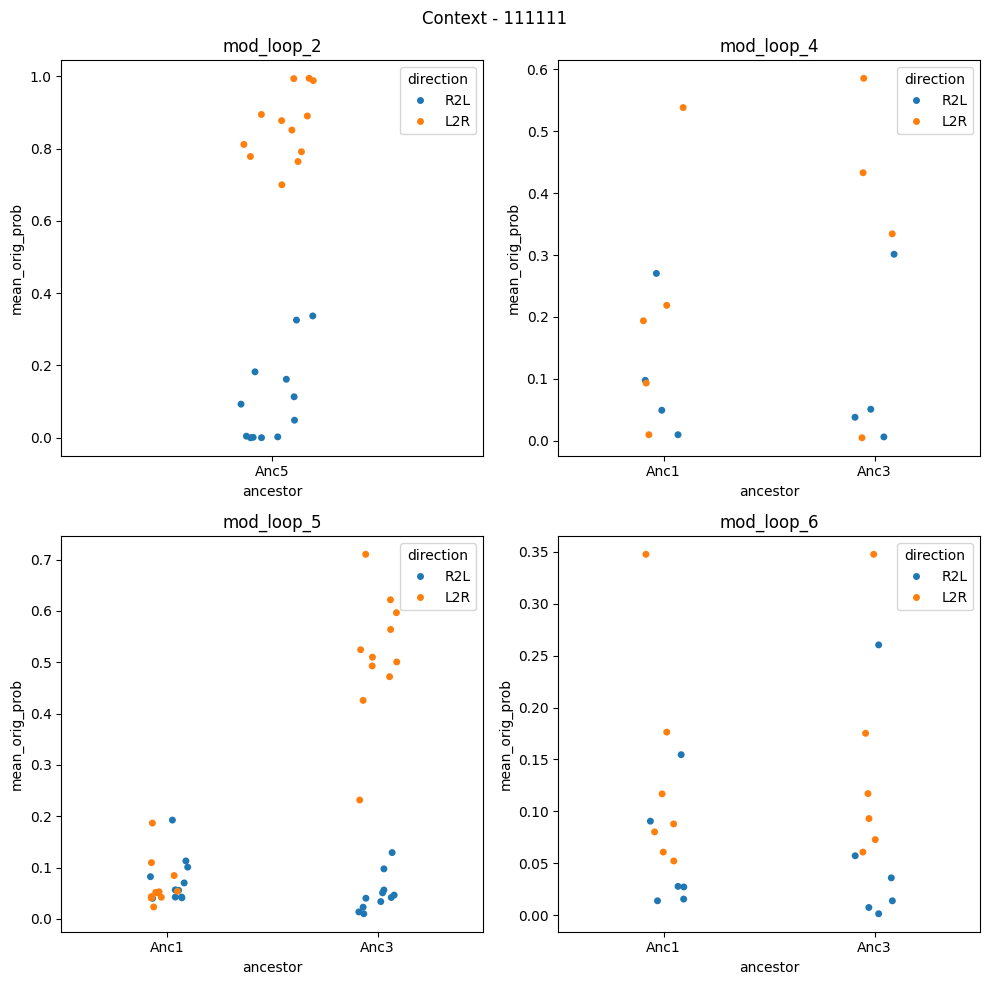

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


mod_loops = [2,4,5,6]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize = (10,10))

for k, loop in enumerate(mod_loops):

    j = k % 2 
    i = int(k / 2)

    ancestors_table_mod_loop = ancestors_table.loc[ancestors_table["mod_loop_id"] == loop, : ].copy()
    ancestors_table_mod_loop["direction"] = ancestors_table_mod_loop["seq_id"].apply(lambda x: "L2R" if x.split("_")[2][0] == "1" else "R2L")
    ancestors_table_mod_loop["ancestor"] = ancestors_table_mod_loop["seq_id"].apply(lambda x: x.split('_')[0])
    sns.stripplot(x = f"ancestor", y = "mean_orig_prob", data=ancestors_table_mod_loop, ax = axes[i][j], hue = "direction")
    axes[i][j].set_title(f"mod_loop_{loop}")
    
plt.suptitle(f'Context - {context_loops}')
plt.tight_layout()

# plt.savefig(f"./figures/Context_{context_loops}_mod_loop_only_direction.png")

0 0
0 1
0 2
1 0
1 1
1 2


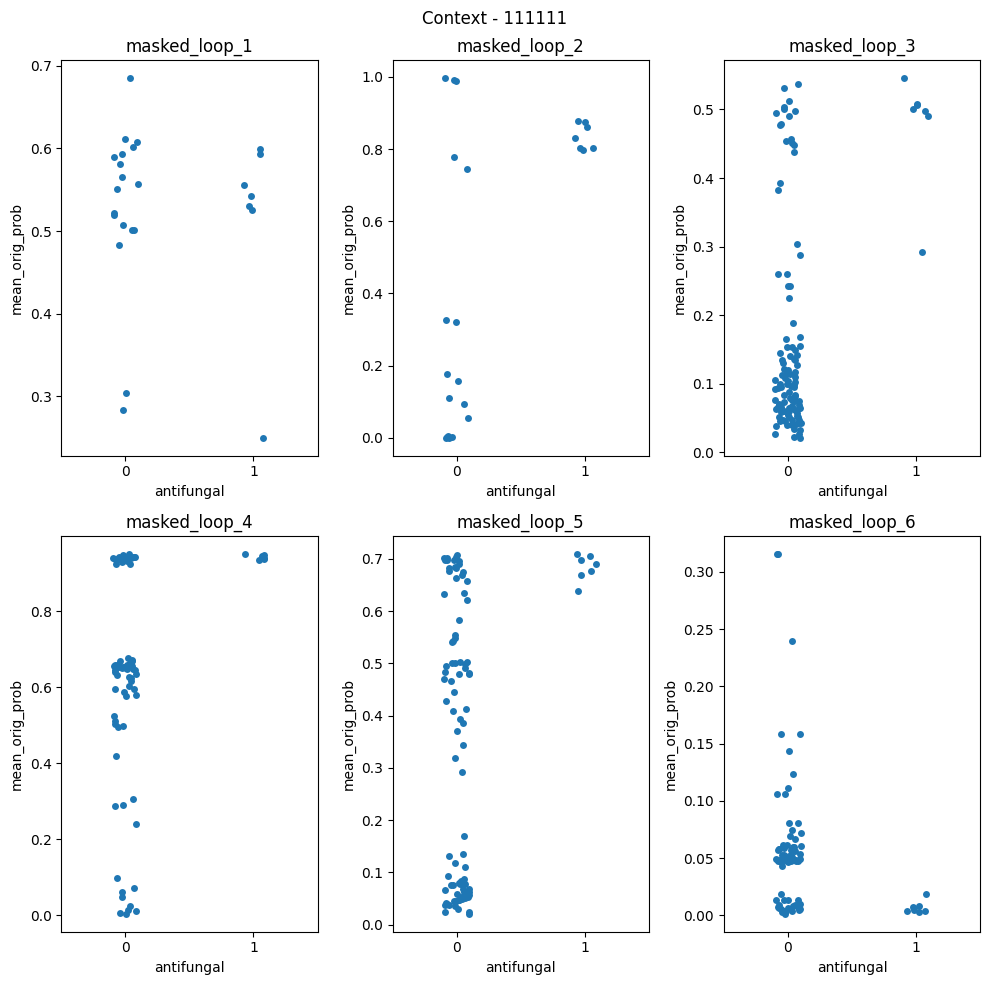

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


masked_loops = [1,2,3,4,5,6]
ncols = 3
nrows = int(len(masked_loops)/ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize = (10,10))

for k, loop in enumerate(masked_loops):

    j = k % ncols 
    i = int(k / ncols)

    ancestors_table_mod_loop = ancestors_table.loc[ancestors_table["masked_loop_id"] == loop, : ].copy()
    sns.stripplot(x = "antifungal", y = "mean_orig_prob", data=ancestors_table_mod_loop, ax = axes[i][j])
    axes[i][j].set_title(f"masked_loop_{loop}")
    
    
plt.suptitle(f'Context - {context_loops}')
plt.tight_layout()

plt.savefig(f"./figures/antifungal_context_{context_loops}_single_loops.png")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize = (10,10))

for loop in list(range(1,6)):

    j = (loop - 1) % 3 
    i = int((loop -1) / 3)

    ancestors_table[f"L{loop}_present"] = list((~ancestors_table[f"mean_orig_prob_L{loop}"].isna()))
    sns.stripplot(x = f"L{loop}_present", y = "mean_orig_prob", data=ancestors_table, ax = axes[i][j])
    
plt.suptitle(f'Context - {context_loops}')
plt.tight_layout()

plt.savefig(f"./figures/Context_{context_loops}_loop_diff.png")

### Testing Anti-fungal Variants

In [12]:
Antifungal_chitinase_seqs = np.array([list(x[1]) for x in Antifungal_chitinases]) 
Antifungal_chitinase_seqs = Antifungal_chitinase_seqs[:,165:-12]
Antifungal_chitinase_seqs = np.concatenate((Antifungal_chitinase_seqs[:,:96], Antifungal_chitinase_seqs[:,97:]), axis = 1)
Antifungal_chitinase_seqs = [''.join(x) for x in Antifungal_chitinase_seqs.tolist()]
    
Antifungal_chitinase_names = [x[0] for x in Antifungal_chitinases]
Antifungal_chitinases_clean = [(a,b) for a,b in zip(Antifungal_chitinase_names, Antifungal_chitinase_seqs)]
del Antifungal_chitinases_clean[9]

In [13]:
# loops_to_include = [2] # Choose a list with elements [1,2,3,4,5,6]
loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

output_table = []

# for loop_number in range(2,3):

#     loops_to_include = [loop_number]
#     loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

for seq in Antifungal_chitinases_clean:
    
    actual_loop_seqs = []
    actual_loop_lens = []
    actual_loop_start_points = []

    offset = 0

    for i in range(len(Loop_start_points)):

        loop_MSA_start = Loop_start_points[i]
        loop_MSA_len = Loop_lengths[i]
        loop_MSA_seq = seq[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

        loop_seq_actual = loop_MSA_seq.replace("-","")
        loop_len_actual = len(loop_seq_actual)

        actual_loop_seqs.append(loop_seq_actual)
        actual_loop_lens.append(len(loop_seq_actual))
        actual_loop_start_points.append(loop_MSA_start - offset)

        offset += loop_MSA_len - loop_len_actual 

    actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include_ind].tolist()
    actual_loop_lens = np.array(actual_loop_lens)[loops_to_include_ind].tolist()
    actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include_ind].tolist()

    try:        
        output = fim([seq[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, 
                    original_length_list = actual_loop_lens, gen_length_list = actual_loop_lens, loop_numbers=loops_to_include)
    except:
        continue
    
    if output == None:
        continue
    
    output_table_record = {"seq_id": seq[0]}

    for ind, k in enumerate(loops_to_include_ind):

        true_loop_number = inverse_loop_map[k]

        output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                    f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind],
                                    f"median_orig_prob_L{true_loop_number}":output["median_orig_prob"][ind], f"median_pred_prob_L{true_loop_number}":output["median_pred_prob"][ind]})
        
        # output_table_record.update({f"loop_number": true_loop_number, "orig_loop": actual_loop_seqs[ind], "pred_loop": output["pred_seqs"][ind],
        #                             f"mean_orig_prob":output["average_orig_prob"][ind], f"mean_pred_prob":output["average_pred_prob"][ind],
        #                             f"median_orig_prob":output["median_orig_prob"][ind], f"median_pred_prob":output["median_pred_prob"][ind]})

    output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"], 
                                "mean_pred_prob": output["overall_average_pred_prob"]})
    
    output_table.append(output_table_record)
    
        
antifungal_table = pd.DataFrame(output_table)
antifungal_table["antifungal"] = 1          




        
        

NameError: name 'loops_to_include' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()

sns.violinplot(x = "loop_number", y = "mean_orig_prob", data = antifungal_table, ax = axes)
axes.set_title(f"Context - {context_loops}")

plt.savefig(f"./figures/antifungal_context_{context_loops}_all_loops.png")

In [ ]:
common_cols = ["seq_id","mean_orig_prob","mean_pred_prob","antifungal"]

combined_table = pd.concat((ancestors_table[common_cols], antifungal_table[common_cols]), axis = 0).reset_index(drop=True)
combined_table = combined_table.drop_duplicates(subset=["seq_id"])

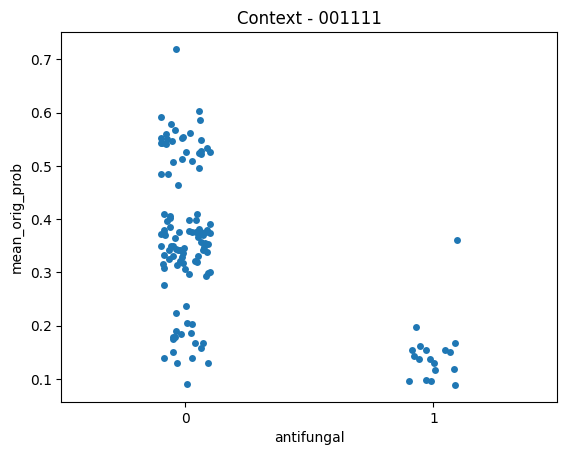

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots()

sns.stripplot(x = "antifungal", y = "mean_orig_prob", data = combined_table, ax = axes)
axes.set_title(f"Context - {context_loops}")

plt.savefig(f"./figures/antifungal_context_{context_loops}_all_loops_avg.png")

### Testing other chitinases

In [ ]:
loops_to_include = [2] # Choose a list with elements [1,2,3,4,5,6]
loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

output_table = []

for ancestor in GH19_MSA:
    
    actual_loop_seqs = []
    actual_loop_lens = []
    actual_loop_start_points = []

    offset = 0

    for i in range(len(Loop_start_points)):

        loop_MSA_start = Loop_start_points[i]
        loop_MSA_len = Loop_lengths[i]
        loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

        loop_seq_actual = loop_MSA_seq.replace("-","")
        loop_len_actual = len(loop_seq_actual)

        actual_loop_seqs.append(loop_seq_actual)
        actual_loop_lens.append(len(loop_seq_actual))
        actual_loop_start_points.append(loop_MSA_start - offset)

        offset += loop_MSA_len - loop_len_actual 

    # if all_loops:

    actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include].tolist()
    actual_loop_lens = np.array(actual_loop_lens)[loops_to_include].tolist()
    actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include].tolist()
        
    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, original_length_list= actual_loop_lens, gen_length_list=actual_loop_lens)
    
    if output == None:
        continue
    
    output_table_record = {"seq_id": ancestor[0]}

    for ind, k in enumerate(loops_to_include):

        true_loop_number = inverse_loop_map[k]

        output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                    f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

    output_table.append(output_table_record)

output_table = pd.DataFrame(output_table)        

### Testing framework regions

In [127]:
GH19_ancestor_seqs = [list(anc[1]) for anc in GH19_ancestors[1:-1]]
GH19_ancestor_seqs = np.array(GH19_ancestor_seqs)
GH19_ancestor_seqs = GH19_ancestor_seqs[:,5:]
GH19_ancestor_seqs[:94,13] = GH19_ancestor_seqs[:94,20]
GH19_ancestor_seqs[:94, 20] = "-"
GH19_ancestor_seqs = GH19_ancestor_seqs[:,:-14]
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:202], GH19_ancestor_seqs[:,207:]), axis=1)
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:93], GH19_ancestor_seqs[:,94:]), axis=1)
GH19_ancestor_seqs = GH19_ancestor_seqs.tolist()
GH19_ancestor_seqs = [''.join(x) for x in GH19_ancestor_seqs]

GH19_ancestor_names = [seq[0] for seq in GH19_ancestors[1:-1]]
GH19_ancestors_clean = [(a,b) for a,b in zip(GH19_ancestor_names, GH19_ancestor_seqs)]

In [128]:
context_loops = "111111"

In [129]:
Loop_lengths = [7,13, 8, 5, 12, 7]
Loop_start_points = [14, 64, 91, 156, 170, 231]
Loop_end_points = [a + b - 1 for a,b in zip(Loop_start_points, Loop_lengths)]



Loop_ID_mappings = {"LI":1, "LII":2, "LIII":3,"LIV":4,"LV":5,"LC":6}

In [130]:
import numpy as np

def mask_fw_regions(seqlen, Loop_start_points, Loop_lengths):

    fw_region_start_points = [0] + [a + b for a,b in zip(Loop_start_points, Loop_lengths)][:-1]
    fw_region_end_points = [x - 1 for x in Loop_start_points]

    fw_regions = [(a,b) for a,b in zip(fw_region_start_points, fw_region_end_points)]
    fw_regions_ind = set(range(len(fw_regions)))
    masked_fw_lengths = sorted(Loop_lengths)[::-1]

    masked_fw_start_points = []

    i = 0
    all_positions = set(range(seqlen))

    while i < len(masked_fw_lengths):
        fw_region_ind = np.random.choice(list(fw_regions_ind),1, replace=False)[0]
        region_start, region_end = fw_regions[fw_region_ind][0], fw_regions[fw_region_ind][1]
        mask_start = np.random.choice(range(region_start, region_end + 1), 1, replace=False)[0]
        mask_end = mask_start + masked_fw_lengths[i] - 1
        if mask_end > region_end:
            continue
        elif mask_start not in all_positions or mask_end not in all_positions:
            continue
        else:
            masked_fw_start_points.append(mask_start)
            i += 1
            all_positions = all_positions - set(range(mask_start, mask_end + 1))
            fw_regions_ind = fw_regions_ind - set([fw_region_ind])

    sorted_start_point_inds = np.argsort(masked_fw_start_points)
    masked_fw_start_points = np.array(masked_fw_start_points)[sorted_start_point_inds].tolist()
    masked_fw_lengths = np.array(masked_fw_lengths)[sorted_start_point_inds].tolist()

    return masked_fw_start_points, masked_fw_lengths

def mask_fw_regions_predefined(seqlen, fw_regions):

    ext_threshold = 5
    ext_fails = 0

    while ext_fails < ext_threshold:

        threshold = 200
        failed_attempts = 0

        fw_regions_ind = set(range(len(fw_regions)))
        masked_fw_lengths = sorted(Loop_lengths)[::-1]

        masked_fw_start_points = []

        i = 0
        all_positions = set(range(seqlen))

        while i < len(masked_fw_lengths) and failed_attempts < threshold:
            fw_region_ind = np.random.choice(list(fw_regions_ind),1, replace=False)[0]
            region_start, region_end = fw_regions[fw_region_ind][0], fw_regions[fw_region_ind][1]
            max_mask_start_point = region_end - masked_fw_lengths[i] + 1

            if max_mask_start_point < region_start:
                continue

            mask_start = np.random.choice(range(region_start, max_mask_start_point + 1), 1, replace=False)[0]
            mask_end = mask_start + masked_fw_lengths[i] - 1
            if mask_end > region_end:
                failed_attempts += 1
                continue
            elif mask_start not in all_positions or mask_end not in all_positions:
                failed_attempts += 1
                continue
            else:
                masked_fw_start_points.append(mask_start)
                i += 1
                all_positions = all_positions - set(range(mask_start, mask_end + 1))
                # fw_regions_ind = fw_regions_ind - set([fw_region_ind])

        if failed_attempts == threshold:
            ext_fails += 1
            continue

        sorted_start_point_inds = np.argsort(masked_fw_start_points)
        masked_fw_start_points = np.array(masked_fw_start_points)[sorted_start_point_inds].tolist()
        masked_fw_lengths = np.array(masked_fw_lengths)[sorted_start_point_inds].tolist()

        return masked_fw_start_points, masked_fw_lengths
    
    raise Exception("Max attempts of choosing segment sets exceeded. Maybe not possible to choose a valid set of segments.")
        



In [131]:
def get_common_available_fw_regions(ancestor_variants, Loop_start_points, Loop_lengths):

    available_pos = set()

    anc_loop_seqs = []
    anc_loop_lens = []
    anc_loop_ranges = []
    seq_lens = []

    for ancestor in ancestor_variants:

        actual_loop_seqs = []
        actual_loop_lens = []
        actual_loop_ranges = []

        offset = 0

        for i in range(len(Loop_start_points)):

                loop_MSA_start = Loop_start_points[i]
                loop_MSA_len = Loop_lengths[i]
                loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

                loop_seq_actual = loop_MSA_seq.replace("-","")
                loop_len_actual = len(loop_seq_actual)

                actual_loop_seqs.append(loop_seq_actual)
                actual_loop_lens.append(loop_len_actual)

                loop_start = loop_MSA_start - offset
                loop_end = loop_MSA_start - offset + loop_len_actual - 1

                if loop_end >= loop_start:
                    actual_loop_ranges.append((loop_start,loop_end))

                offset += loop_MSA_len - loop_len_actual

        anc_loop_seqs.append(actual_loop_seqs)
        anc_loop_lens.append(actual_loop_lens)
        anc_loop_ranges.append(actual_loop_ranges)
        seq_lens.append(len(ancestor[1].replace("-","")))

    max_seq_len = min(seq_lens)
    available_pos = set(range(max_seq_len))

    for i in range(len(GH19_ancestors_clean)):

        for loop_range in anc_loop_ranges[i]:
            
            available_pos  = available_pos - set(range(loop_range[0], loop_range[1]))

    available_pos = sorted(list(available_pos))

    available_ranges = []

    start_flag = 1

    for i,pos in enumerate(available_pos[:-1]):

        if start_flag == 1:
            seg_start = pos

        if i == len(available_pos) - 2:
            seg_end = available_pos[i] + 1
            available_ranges.append((seg_start, seg_end))
            continue

        if pos + 1 == available_pos[i + 1]:
            start_flag = 0
            continue
        else:
            seg_end = pos
            start_flag = 1
            available_ranges.append((seg_start, seg_end))

    return available_ranges

def get_common_fw_regions_from_MSA(sequences, MSA_Loop_start_points, MSA_Loop_end_points):

    Loop_ranges = [(a,b) for a,b in zip(MSA_Loop_start_points, MSA_Loop_end_points)]

    fw_regions = []

    for i in range(len(Loop_ranges)):
        
        if i == 0:
            fw_regions.append((0,Loop_ranges[i][0] - 1))
            continue
        
        fw_regions.append((Loop_ranges[i-1][1] + 1, Loop_ranges[i][0] - 1))
    
    fw_regions_ind = set(range(len(fw_regions)))

    sorted_loop_length_inds = np.argsort(Loop_lengths)[::-1]
    masked_fw_lengths = np.array(Loop_lengths)[sorted_loop_length_inds].tolist()
    sorted_loop_ids = np.array(range(1,7))[sorted_loop_length_inds].tolist()

    masked_fw_start_points = []
    seqlen = len(sequences[0][1])

    i = 0
    all_positions = set(range(seqlen))

    while i < len(masked_fw_lengths):
        fw_region_ind = np.random.choice(list(fw_regions_ind),1, replace=False)[0]
        region_start, region_end = fw_regions[fw_region_ind][0], fw_regions[fw_region_ind][1]

        max_mask_start_point = region_end - masked_fw_lengths[i] + 1

        if max_mask_start_point < region_start:
            continue

        mask_start = np.random.choice(range(region_start, max_mask_start_point + 1), 1, replace=False)[0]
        mask_end = mask_start + masked_fw_lengths[i] - 1

        if mask_end > region_end:
            print("check")
            continue
        elif mask_start not in all_positions or mask_end not in all_positions:
            print("check 2")
            continue
        else:
            masked_fw_start_points.append(mask_start)
            i += 1
            all_positions = all_positions - set(range(mask_start, mask_end + 1))
            fw_regions_ind = fw_regions_ind - set([fw_region_ind])

    sorted_start_point_inds = np.argsort(masked_fw_start_points)
    masked_fw_start_points = np.array(masked_fw_start_points)[sorted_start_point_inds].tolist()
    masked_fw_lengths = np.array(masked_fw_lengths)[sorted_start_point_inds].tolist()
    sorted_loop_ids = np.array(sorted_loop_ids)[sorted_start_point_inds].tolist()

    return masked_fw_start_points, masked_fw_lengths, sorted_loop_ids


    

In [133]:
from tqdm import tqdm
from scipy.stats import pearsonr

modified_loop_only = False
num_ext_simulations = 50
num_simulations = 1
fw_to_ind_map = loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

fws_to_include = [1,2,3,4,5,6]
fws_to_include_ind = [fw_to_ind_map[x] for x in fws_to_include]

context_path = f"./contexts/loops_{context_loops}.fasta"
context_seqs_MSA = read_msa(context_path)

inverse_fw_map = inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

correlations_list = []
fw_start_points_list = []
fw_lengths_list = []
current_loop_list = []
sim_number_list = []
sorted_loop_ids_list = []

for cur_loop in [1,2,3,4,5,6]:

    fws_to_include = [cur_loop]
    
    np.random.seed(42)

    for ext_sim in tqdm(range(num_ext_simulations)):

        fw_start_points, fw_lengths, sorted_loop_ids = get_common_fw_regions_from_MSA(GH19_ancestors_clean, Loop_start_points, Loop_end_points)
        # fw_start_points, fw_lengths, sorted_loop_ids = [21,51,99,123,194,217],[8,13,5,7,7,12],[3,2,4,6,1,5]
        # fw_start_points, fw_lengths, sorted_loop_ids = [6, 36, 80, 107, 162, 188],[5, 13, 7, 7, 8, 12],[4,2,1,6,3,5]
        
        sorted_loop_ids = np.array(sorted_loop_ids)
        fw_to_ind_map = {k:v for k,v in zip(sorted_loop_ids, range(len(sorted_loop_ids)))}
        # fws_to_include = list(sorted_loop_ids)
        fws_to_include_ind = [fw_to_ind_map[x] for x in fws_to_include]
        

        output_table = []

        count = 0
        
        for ancestor in GH19_ancestors_clean:
            
            name_split = ancestor[0].split('_')
            total_seqlen = len(ancestor[1].replace("-",""))

            max_to_actual_len_dict = {}

            if len(name_split) == 3:

                anc_id = name_split[0]
                mod_loop_name = name_split[1]
                mod_loop_number = Loop_ID_mappings[mod_loop_name]

                mod_loop_ind = fw_to_ind_map[mod_loop_number]
                
                actual_loop_seqs = []
                actual_loop_lens = []
                actual_loop_start_points = []

                offset = 0

                if name_split[2].startswith("1"):
                    direction = "L2R"
                else:
                    direction = "R2L"

                for i in range(len(Loop_start_points)):

                    loop_MSA_start = Loop_start_points[i]
                    loop_MSA_len = Loop_lengths[i]
                    loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

                    loop_seq_actual = loop_MSA_seq.replace("-","")
                    loop_len_actual = len(loop_seq_actual)

                    if loop_MSA_len not in list(max_to_actual_len_dict.keys()):
                        max_to_actual_len_dict[loop_MSA_len] = [loop_len_actual]
                    else:
                        max_to_actual_len_dict[loop_MSA_len].append(loop_len_actual)

                    actual_loop_seqs.append(loop_seq_actual)
                    actual_loop_lens.append(loop_len_actual)
                    actual_loop_start_points.append(loop_MSA_start - offset)

                    offset += loop_MSA_len - loop_len_actual 

                offset = 0

                actual_fw_seqs = []
                actual_fw_lens = []
                actual_fw_start_points = []

                for i in range(len(fw_start_points)):

                    fw_MSA_start = fw_start_points[i]
                    fw_MSA_len = fw_lengths[i]
                    fw_MSA_seq = ancestor[1][fw_MSA_start: fw_MSA_start + fw_MSA_len]

                    fw_len_actual = max_to_actual_len_dict[fw_MSA_len].pop()

                    if direction == "L2R":
                        fw_seq_actual = ancestor[1][fw_MSA_start: fw_MSA_start + fw_len_actual]
                    else:
                        fw_seq_actual = ancestor[1][fw_MSA_start + fw_MSA_len - fw_len_actual: fw_MSA_start + fw_MSA_len]

                    actual_fw_seqs.append(fw_seq_actual)
                    actual_fw_lens.append(fw_len_actual)
                    actual_fw_start_points.append(fw_MSA_start - offset)

                    offset += Loop_lengths[i] - actual_loop_lens[i] 
                
                if not modified_loop_only:

                    actual_fw_seqs = np.array(actual_fw_seqs)[fws_to_include_ind].tolist()
                    actual_fw_lens = np.array(actual_fw_lens)[fws_to_include_ind].tolist()
                    actual_fw_start_points = np.array(actual_fw_start_points)[fws_to_include_ind].tolist()


                    for sim in range(num_simulations):

                        output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = actual_fw_start_points, 
                                    original_length_list = actual_fw_lens, gen_length_list = actual_fw_lens, loop_numbers=fws_to_include,autoreg=False)
                                                    
                        if output == None:
                            continue
                        
                        output_table_record = {"seq_id": ancestor[0], "antifungal": int(ancestor[0] in Antifungal_chitinase_names), "mod_loop_id": mod_loop_number,"sim_ind": sim + 1}

                        for ind, k in enumerate(fws_to_include_ind):

                            true_loop_number = inverse_loop_map[k]
                            
                            output_table_record.update({f"orig_L{true_loop_number}": actual_fw_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                                        f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

                        output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"],
                                                    "mean_pred_prob": output["overall_average_pred_prob"],
                                                    })
                        
                        output_table.append(output_table_record)
                    
                else:

                    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = [actual_fw_start_points[mod_loop_ind]],
                                original_length_list = [actual_fw_lens[mod_loop_ind]], gen_length_list = [actual_fw_lens[mod_loop_ind]], 
                                loop_numbers=[mod_loop_number]) 
                    
                    if output == None:
                        continue
                    
                    output_table.append({"sim_number":ext_sim, "seq_id": ancestor[0], "masked_loop":mod_loop_number,
                                        "mod_loop_id": mod_loop_number, "antifungal": int(ancestor[0] in Antifungal_chitinase_names),
                                        "orig_loop": actual_fw_seqs[mod_loop_ind], "pred_loop": output["pred_seqs"][0],
                                        "mean_orig_prob":np.mean(output["average_orig_prob"]), "mean_pred_prob":np.mean(output["average_pred_prob"]),
                                        "median_orig_prob":np.median(output["median_orig_prob"]), "median_pred_prob":np.median(output["median_pred_prob"])})
                

        if len(output_table) == 0:
            continue
                
        ancestors_table = pd.DataFrame(output_table)

        relevant_cols = ["seq_id","mod_loop_id","mean_orig_prob",]

        ancestor_table_agg = ancestors_table[relevant_cols].groupby(by=["seq_id","mod_loop_id"]).agg([np.mean, np.std]).reset_index()
        ancestor_table_agg.columns = ["_".join([a,b]) if b else a for a,b in ancestor_table_agg.columns]

        ancestor_table_agg = ancestor_table_agg.merge(all_anc_table, left_on="seq_id", right_on="name")

        all_anc_table_tm = ancestor_table_agg.dropna(subset=["Tm"])
        pearson_corr = pearsonr(x=all_anc_table_tm["mean_orig_prob_mean"], y = all_anc_table_tm["Tm"]).statistic

        current_loop_list.append(cur_loop)
        correlations_list.append(pearson_corr)
        fw_start_points_list.append(fw_start_points)
        fw_lengths_list.append(fw_lengths)
        sim_number_list.append(ext_sim)
        sorted_loop_ids_list.append(sorted_loop_ids)


 36%|███▌      | 18/50 [15:37<27:46, 52.09s/it]


KeyboardInterrupt: 

In [116]:
actual_fw_lens

[1]

In [126]:
import pickle as pkl
import pandas as pd

with open("correlations_list_loops_global.pkl","rb") as f:
    correlations_list_loops = pkl.load(f)

In [128]:
correlations_table = pd.DataFrame()

correlations_table["loop_tm_correlations"] = correlations_list_loops
# correlations_table["current_loop"] = current_loop_list
correlations_table["sim_number"] = sim_number_list
correlations_table["fw_tm_correlations"] = correlations_list
correlations_table["fw_start_points"] = fw_start_points_list
correlations_table["fw_lengths"] = fw_lengths_list
correlations_table["fw_regions"] = correlations_table.apply(lambda x: [[a,a + b - 1] for a,b in zip(x["fw_start_points"], x["fw_lengths"])], axis = 1)
# correlations_table["loop_order"] = sorted_loop_ids_list

correlations_table.to_csv("correlations_table_specific_fw_region_v2_best.tsv", sep="\t", index = False)


In [136]:
import ast
import numpy as np
import re

correlations_table = pd.read_csv("correlations_table_single_regions.tsv", sep = "\t")
correlations_table["fw_regions"] = correlations_table["fw_regions"].apply(ast.literal_eval)
correlations_table["loop_order"] = correlations_table["loop_order"].apply(lambda s: list(map(int, re.findall(r"-?\d+", s))))


In [134]:
all_sites_correlation_sums = np.zeros(238)/1.0
all_sites_correlation_counts = np.zeros(238)/1.0
all_sites_correlation_sums_avg = np.zeros(238)/1.0

for i in range(len(correlations_table)):

    sites_flag = np.zeros(238)
    chosen_fw_sites = np.concatenate([list(range(a[0],a[1] + 1)) for a in correlations_table["fw_regions"][i]])
    sites_flag[chosen_fw_sites] = 1
    all_sites_correlation_sums += sites_flag * correlations_table["fw_tm_correlations"][i]
    all_sites_correlation_counts += sites_flag

all_sites_correlation_sums_avg[all_sites_correlation_counts > 0] = all_sites_correlation_sums[all_sites_correlation_counts > 0]/all_sites_correlation_counts[all_sites_correlation_counts > 0]


In [137]:
all_sites_correlation_sums = np.zeros(238)/1.0
all_sites_correlation_counts = np.zeros(238)/1.0
# all_sites_correlation_sums_avg = np.zeros(238)/1.0

for i in range(len(correlations_table)):

    sites_flag = np.zeros(238)

    cur_regions = np.array(correlations_table["fw_regions"][i])
    cur_loop = correlations_table["current_loop"][i]
    loop_order = correlations_table["loop_order"][i]

    is_cur_loop = loop_order == cur_loop 
    chosen_region = list(cur_regions[is_cur_loop][0])
    
    chosen_fw_sites = np.array(range(chosen_region[0],chosen_region[1] + 1))
    sites_flag[chosen_fw_sites] = 1
    all_sites_correlation_sums += sites_flag * correlations_table["fw_tm_correlations"][i]
    all_sites_correlation_counts += sites_flag

all_sites_correlation_sums_avg[all_sites_correlation_counts > 0] = all_sites_correlation_sums[all_sites_correlation_counts > 0]/all_sites_correlation_counts[all_sites_correlation_counts > 0]

In [135]:
loop_regions = list(range(14,21)) + list(range(64,77)) + list(range(91,99)) + list(range(156,161)) + list(range(170,182)) + list(range(231,238))

loop_indicator = [True if x in loop_regions else False for x in range(238)]

bar_labels = ['loop' if x else 'framework' for x in loop_indicator]
bar_colors = ['tab:red' if x else 'tab:blue' for x in loop_indicator]

all_sites_correlation_sums_avg[loop_indicator] = correlations_table["loop_tm_correlations"].mean()

In [138]:
loop_regions_list = list(range(14,21)), list(range(64,77)), list(range(91,99)), list(range(156,161)), list(range(170,182)), list(range(231,238))
loop_regions = list(range(14,21)) + list(range(64,77)) + list(range(91,99)) + list(range(156,161)) + list(range(170,182)) + list(range(231,238))

loop_indicator = [True if x in loop_regions else False for x in range(238)]

bar_labels = ['loop' if x else 'framework' for x in loop_indicator]
bar_colors = ['tab:red' if x else 'tab:blue' for x in loop_indicator]

for i, sites in enumerate(loop_regions_list):
    all_sites_correlation_sums_avg[sites] = correlations_table.loc[correlations_table["current_loop"] == i+1]["loop_tm_correlations"].mean()

Text(0.5, 0, 'MSA site number')

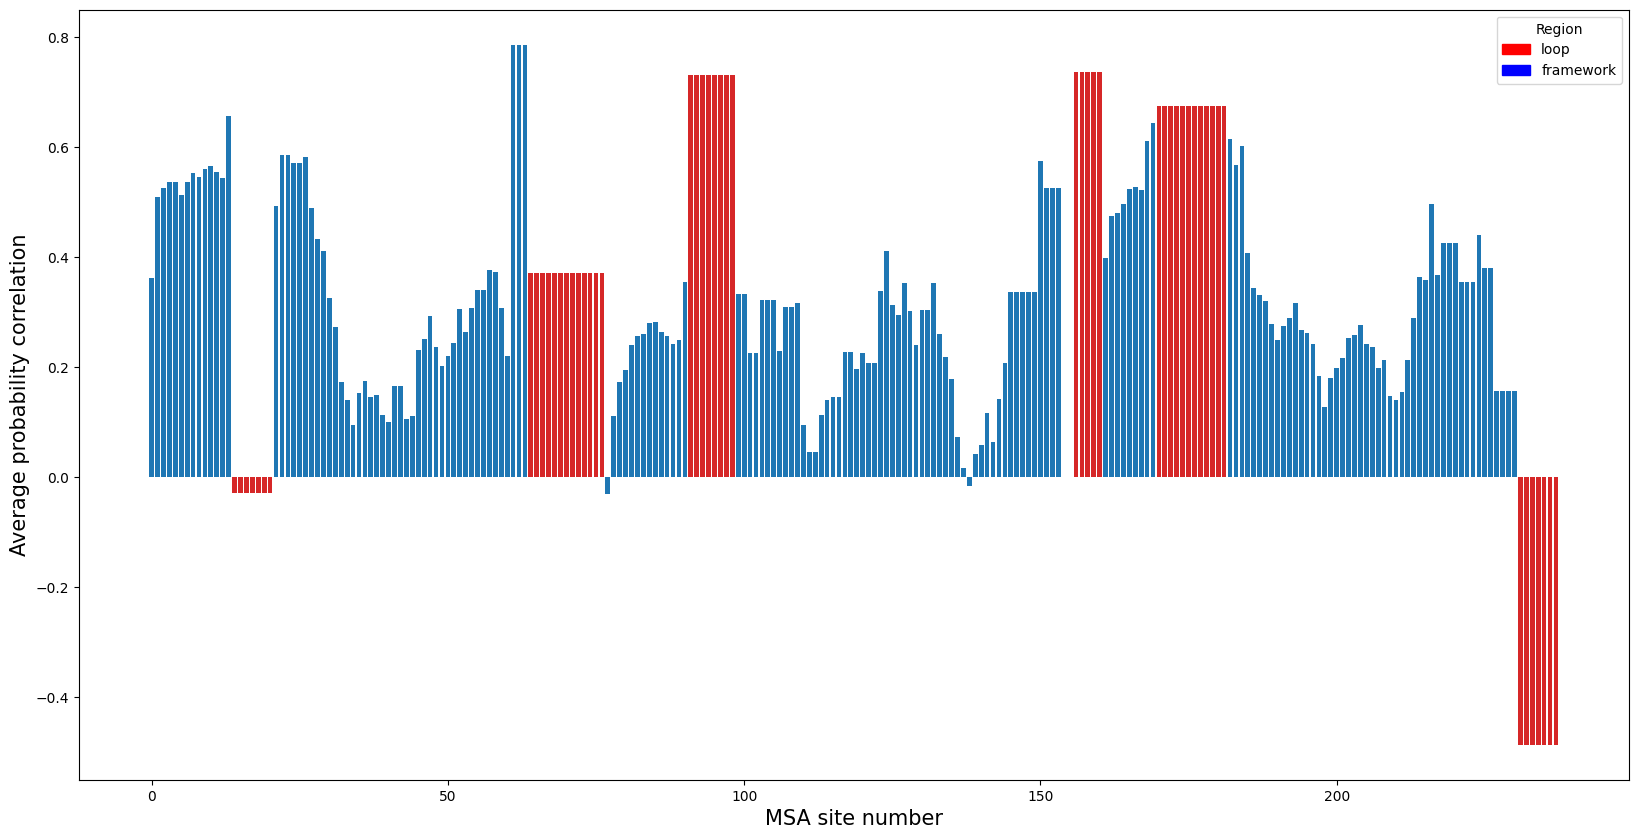

In [139]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize = (20,10))

patches = [mpatches.Patch(color='red', label='loop'), mpatches.Patch(color='blue', label='framework')]


ax.bar(x = np.arange(238), height=all_sites_correlation_sums_avg, color = bar_colors)
ax.legend(title='Region', handles = patches)
ax.set_ylabel("Average probability correlation", fontsize = 15)
ax.set_xlabel("MSA site number", fontsize = 15)

# plt.savefig(f"./figures/Tm correlations/Context_{context_loops}_per_site_avg_correlations_inc_loops_specific_fw_v2_best.png")


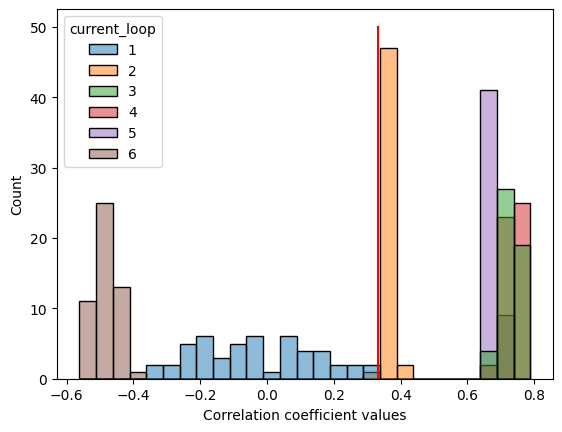

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

mean_loop = correlations_table["loop_tm_correlations"].mean()
mean_fw = correlations_table["fw_tm_correlations"].mean()

correlations_table["current_fw"] = correlations_table["current_loop"]

fig, ax = plt.subplots()

sns.histplot(data = correlations_table, x = "loop_tm_correlations",hue="current_loop", ax=ax, binwidth = 0.05, palette="tab10")
ax.plot([mean_loop, mean_loop],[0,50],"r-")

# sns.histplot(data = correlations_table, x = "fw_tm_correlations", hue="current_fw", ax=ax, binwidth = 0.05, palette="tab10")
# ax.plot([mean_fw, mean_fw],[0,15],"g-")

ax.set_xlabel("Correlation coefficient values")
# plt.legend(loc = "best")

plt.savefig(f"./figures/Tm correlations/Context_{context_loops}_corr_values_hist_Tm_loop_single_region.png")

<AxesSubplot:xlabel='current_loop', ylabel='loop_tm_correlations'>

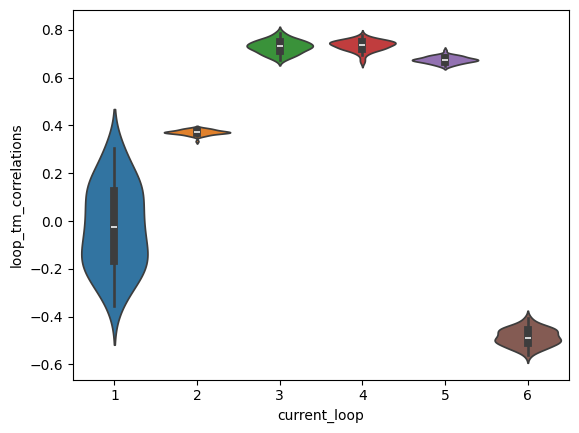

In [147]:
sns.violinplot(data = correlations_table, x = "current_loop",y="loop_tm_correlations", hue="current_loop", legend=False, palette="tab10", density_norm="width")

Text(0.5, 0, 'current_fw')

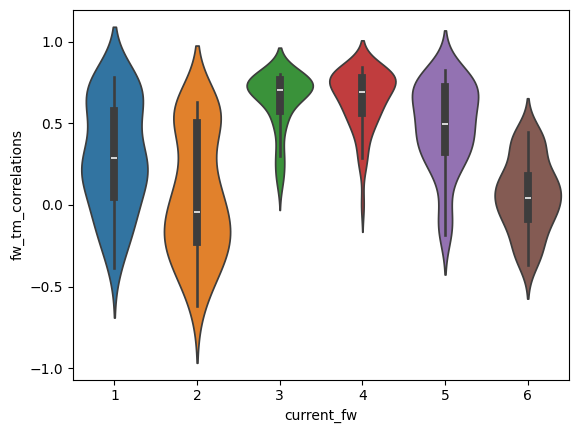

In [149]:
sns.violinplot(data = correlations_table, x = "current_loop",y="fw_tm_correlations", hue="current_loop", legend=False, palette="tab10", density_norm="width")
plt.xlabel("current_fw")

In [152]:
correlations_table = correlations_table.sort_values("fw_tm_correlations").reset_index(drop = True)

In [153]:
correlations_table

,current_loop,sim_number,fw_tm_correlations,fw_start_points,fw_lengths,fw_regions,loop_order,loop_tm_correlations
0,2,36,-0.619621,"[3, 30, 82, 128, 163, 204]","[8, 13, 5, 7, 7, 12]","[[3, 10], [30, 42], [82, 86], [128, 134], [163...","[3, 2, 4, 6, 1, 5]",0.367561
1,2,47,-0.557590,"[7, 23, 81, 114, 163, 198]","[5, 7, 8, 12, 7, 13]","[[7, 11], [23, 29], [81, 88], [114, 125], [163...","[4, 6, 3, 5, 1, 2]",0.368693
2,2,5,-0.487553,"[5, 28, 82, 110, 161, 196]","[5, 8, 7, 13, 7, 12]","[[5, 9], [28, 35], [82, 88], [110, 122], [161,...","[4, 3, 1, 2, 6, 5]",0.358726
3,2,41,-0.422722,"[3, 27, 79, 131, 162, 210]","[7, 13, 7, 5, 8, 12]","[[3, 9], [27, 39], [79, 85], [131, 135], [162,...","[6, 2, 1, 4, 3, 5]",0.384551
4,2,8,-0.407812,"[1, 38, 79, 134, 162, 211]","[8, 13, 7, 5, 7, 12]","[[1, 8], [38, 50], [79, 85], [134, 138], [162,...","[3, 2, 6, 4, 1, 5]",0.372339
...,...,...,...,...,...,...,...,...
295,5,46,0.823936,"[2, 57, 77, 102, 163, 193]","[12, 7, 13, 8, 7, 5]","[[2, 13], [57, 63], [77, 89], [102, 109], [163...","[5, 6, 2, 3, 1, 4]",0.663212
296,4,49,0.826981,"[4, 23, 77, 124, 165, 219]","[8, 12, 13, 7, 5, 7]","[[4, 11], [23, 34], [77, 89], [124, 130], [165...","[3, 5, 2, 6, 4, 1]",0.720680
297,4,34,0.830736,"[3, 54, 78, 106, 165, 199]","[7, 7, 12, 8, 5, 13]","[[3, 9], [54, 60], [78, 89], [106, 113], [165,...","[1, 6, 5, 3, 4, 2]",0.719724
298,4,5,0.835554,"[9, 33, 78, 132, 162, 186]","[5, 7, 12, 13, 8, 7]","[[9, 13], [33, 39], [78, 89], [132, 144], [162...","[4, 1, 5, 2, 3, 6]",0.704350


### Correlating per-column entropies with per-column prob correlations

In [94]:
from scipy.stats import entropy

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

context_array = pd.DataFrame([list(seq[1]) for seq in context_seqs_MSA])

entropies = []

for k in range(context_array.shape[1]):

    entropy_col = entropy(context_array.iloc[:,k].value_counts())
    entropies.append(entropy_col)


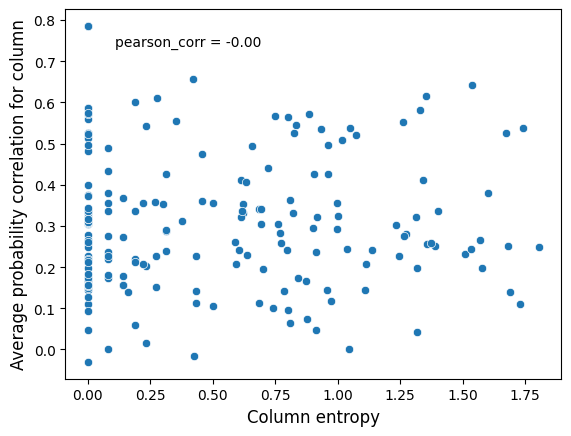

In [98]:
import seaborn as sns
from scipy.stats import pearsonr

fig, axes = plt.subplots()

loop_indicator = np.array(loop_indicator)

sns.scatterplot(x = np.array(entropies)[~loop_indicator], y = all_sites_correlation_sums_avg[~loop_indicator], ax = axes)

pearson_corr = pearsonr(np.array(entropies)[~loop_indicator], all_sites_correlation_sums_avg[~loop_indicator])
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction")
axes.set_xlabel("Column entropy", fontsize = 12)
axes.set_ylabel("Average probability correlation for column", fontsize = 12)

plt.savefig("./figures/Tm correlations/fw_probs_entropy_corr_single_region.png")

### SASA Analysis

In [73]:
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
p = PDBParser(QUIET=1)
# This assumes you have a local copy of 1LCD.pdb in a directory called "PDB"
struct = p.get_structure("4DWX", "./4DWX.pdb")
sr = ShrakeRupley()
sr.compute(struct, level="R")

In [154]:
sasa_values = np.array([struct[0]["A"][i].sasa for i in range(6,243)] + [0])

In [88]:
correlations_table

,loop_tm_correlations,sim_number,fw_tm_correlations,fw_start_points,fw_lengths,fw_regions
39,0.767389,39,-0.150831,"[0, 22, 86, 139, 163, 186]","[12, 7, 5, 13, 7, 8]","[[0, 11], [22, 28], [86, 90], [139, 151], [163..."
5,0.752554,5,0.041235,"[0, 39, 78, 133, 161, 187]","[12, 7, 13, 5, 8, 7]","[[0, 11], [39, 45], [78, 90], [133, 137], [161..."
10,0.735901,10,0.056369,"[5, 45, 77, 115, 163, 204]","[5, 7, 12, 8, 7, 13]","[[5, 9], [45, 51], [77, 88], [115, 122], [163,..."
32,0.749062,32,0.080003,"[6, 32, 83, 105, 161, 201]","[8, 7, 5, 12, 7, 13]","[[6, 13], [32, 38], [83, 87], [105, 116], [161..."
43,0.781429,43,0.082355,"[8, 31, 78, 104, 162, 195]","[5, 8, 7, 12, 7, 13]","[[8, 12], [31, 38], [78, 84], [104, 115], [162..."
23,0.770012,23,0.369444,"[0, 30, 77, 105, 161, 208]","[13, 5, 8, 12, 7, 7]","[[0, 12], [30, 34], [77, 84], [105, 116], [161..."
44,0.778474,44,0.371077,"[1, 26, 78, 134, 163, 221]","[13, 7, 12, 8, 5, 7]","[[1, 13], [26, 32], [78, 89], [134, 141], [163..."
3,0.768272,3,0.374475,"[0, 33, 81, 118, 161, 199]","[12, 7, 5, 13, 7, 8]","[[0, 11], [33, 39], [81, 85], [118, 130], [161..."
1,0.810833,1,0.434111,"[3, 25, 79, 102, 162, 194]","[8, 7, 12, 13, 7, 5]","[[3, 10], [25, 31], [79, 90], [102, 114], [162..."
16,0.774709,16,0.435832,"[0, 37, 78, 105, 161, 184]","[13, 7, 12, 7, 8, 5]","[[0, 12], [37, 43], [78, 89], [105, 111], [161..."


In [94]:
correlations_table = correlations_table.sort_values(by = "fw_tm_correlations").reset_index(drop=True)
worst_fw = correlations_table["fw_regions"].iloc[0]
best_fw = correlations_table["fw_regions"].iloc[-1]

In [98]:
best_fw_sites = np.concatenate([list(range(a[0], a[1] + 1)) for a in best_fw])
worst_fw_sites = np.concatenate([list(range(a[0], a[1] + 1)) for a in worst_fw])

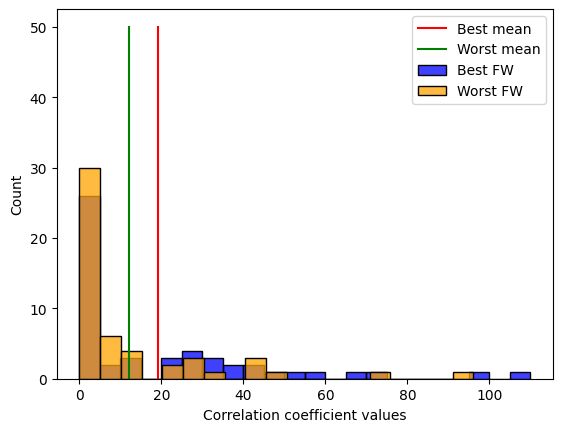

In [99]:
fig, ax = plt.subplots()

mean_sasa_best =  sasa_values[best_fw_sites].mean()
mean_sasa_worst =  sasa_values[worst_fw_sites].mean()

sns.histplot(x = sasa_values[best_fw_sites], binwidth = 5, axes = ax, label = "Best FW", color="blue")
ax.plot([mean_sasa_best, mean_sasa_best],[0,50],"r-", label = "Best mean")

sns.histplot(x = sasa_values[worst_fw_sites], binwidth = 5, axes = ax, label = "Worst FW", color="orange")
ax.plot([mean_sasa_worst, mean_sasa_worst],[0,50],"g-", label = "Worst mean")

plt.legend(loc = "best")
ax.set_xlabel("Correlation coefficient values")

plt.savefig(f"./figures/Tm correlations/Context_{context_loops}_sasa_best_vs_worst_fw.png")

In [59]:
len(sasa_values)

238

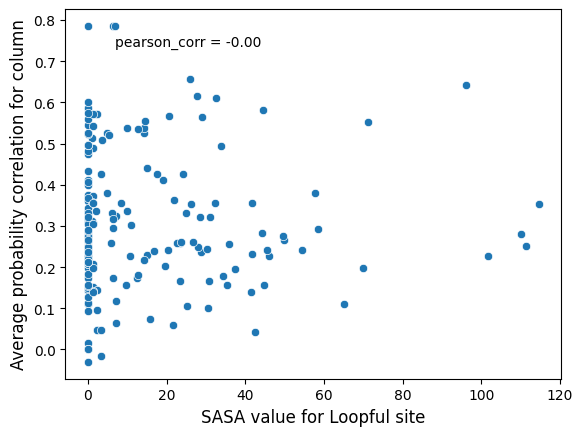

In [102]:
fig, axes = plt.subplots()

sns.scatterplot(x = sasa_values[~loop_indicator], y = all_sites_correlation_sums_avg[~loop_indicator], ax = axes)

pearson_corr = pearsonr(sasa_values[~loop_indicator], all_sites_correlation_sums_avg[~loop_indicator])
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction")
axes.set_xlabel("SASA value for Loopful site", fontsize = 12)
axes.set_ylabel("Average probability correlation for column", fontsize = 12)

plt.savefig("./figures/Tm correlations/fw_probs_sasa_corr_single_region.png")

In [ ]:
from tqdm import tqdm
from scipy.stats import pearsonr

modified_loop_only = False
num_ext_simulations = 10
num_simulations = 1
fw_to_ind_map = loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

fws_to_include = [1,2,3,4,5,6]
fws_to_include_ind = [fw_to_ind_map[x] for x in fws_to_include]

inverse_fw_map = inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)


predefined_fw_regions = get_common_available_fw_regions(GH19_ancestors_clean, Loop_start_points, Loop_lengths)

correlations_list = []

for _ in tqdm(range(num_ext_simulations)):

    output_table = []
    
    for ancestor in tqdm(GH19_ancestors_clean):
        
        name_split = ancestor[0].split('_')
        total_seqlen = len(ancestor[1].replace("-",""))

        if len(name_split) == 3:

            anc_id = name_split[0]
            mod_loop_name = name_split[1]
            mod_loop_number = Loop_ID_mappings[mod_loop_name]

            mod_loop_ind = fw_to_ind_map[mod_loop_number]
            
            actual_loop_seqs = []
            actual_loop_lens = []
            actual_loop_start_points = []

            offset = 0

            for i in range(len(Loop_start_points)):

                loop_MSA_start = Loop_start_points[i]
                loop_MSA_len = Loop_lengths[i]
                loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

                loop_seq_actual = loop_MSA_seq.replace("-","")
                loop_len_actual = len(loop_seq_actual)

                actual_loop_seqs.append(loop_seq_actual)
                actual_loop_lens.append(len(loop_seq_actual))
                actual_loop_start_points.append(loop_MSA_start - offset)

                offset += loop_MSA_len - loop_len_actual  
            
            if not modified_loop_only:

                actual_loop_seqs = np.array(actual_loop_seqs)[fws_to_include_ind].tolist()
                actual_loop_lens = np.array(actual_loop_lens)[fws_to_include_ind].tolist()
                actual_loop_start_points = np.array(actual_loop_start_points)[fws_to_include_ind].tolist()


                for sim in range(num_simulations):

                    # masked_fw_start_points, masked_fw_lengths = mask_fw_regions(total_seqlen, actual_loop_start_points, actual_loop_lens)
                    masked_fw_start_points, masked_fw_lengths = mask_fw_regions_predefined(total_seqlen, predefined_fw_regions)
                        
                    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = masked_fw_start_points, 
                                original_length_list = masked_fw_lengths, gen_length_list = masked_fw_lengths, loop_numbers=fws_to_include,autoreg=True)
                    
                    if output == None:
                        continue
                    
                    output_table_record = {"seq_id": ancestor[0], "antifungal": int(ancestor[0] in Antifungal_chitinase_names), "mod_loop_id": mod_loop_number,"sim_ind": sim + 1}

                    for ind, k in enumerate(fws_to_include_ind):

                        true_loop_number = inverse_loop_map[k]
                        
                        output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                                    f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

                    output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"],
                                                "mean_pred_prob": output["overall_average_pred_prob"],
                                                })
                    
                    output_table.append(output_table_record)
                
            else:

                masked_fw_start_points, masked_fw_lengths = mask_fw_regions(total_seqlen, actual_loop_start_points, actual_loop_lens)

                output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = [masked_fw_start_points[mod_loop_ind]],
                            original_length_list = [masked_fw_lengths[mod_loop_ind]], gen_length_list = [masked_fw_lengths[mod_loop_ind]], 
                            loop_numbers=[mod_loop_number]) 
                
                if output == None:
                    continue
                
                output_table.append({"seq_id": ancestor[0], "masked_loop":mod_loop_number,
                                    "mod_loop_id": mod_loop_number, "antifungal": int(ancestor[0] in Antifungal_chitinase_names),
                                    "orig_loop": actual_loop_seqs[mod_loop_ind], "pred_loop": output["pred_seqs"][0],
                                    "mean_orig_prob":np.mean(output["average_orig_prob"]), "mean_pred_prob":np.mean(output["average_pred_prob"]),
                                    "median_orig_prob":np.median(output["median_orig_prob"]), "median_pred_prob":np.median(output["median_pred_prob"])})
            
            
    ancestors_table = pd.DataFrame(output_table)

    relevant_cols = ["seq_id","mod_loop_id","mean_orig_prob",]

    ancestor_table_agg = ancestors_table[relevant_cols].groupby(by=["seq_id","mod_loop_id"]).agg([np.mean, np.std]).reset_index()
    ancestor_table_agg.columns = ["_".join([a,b]) if b else a for a,b in ancestor_table_agg.columns]

    ancestor_table_agg = ancestor_table_agg.merge(all_anc_table, left_on="seq_id", right_on="name")

    all_anc_table_tm = ancestor_table_agg.dropna(subset=["Tm"])
    pearson_corr = pearsonr(x=all_anc_table_tm["mean_orig_prob_mean"], y = all_anc_table_tm["Tm"]).statistic

    correlations_list.append(pearson_corr)


In [ ]:
relevant_cols = ["seq_id","mod_loop_id","mean_orig_prob",]

ancestor_table_agg = ancestors_table[relevant_cols].groupby(by=["seq_id","mod_loop_id"]).agg([np.mean, np.std]).reset_index()
ancestor_table_agg.columns = ["_".join([a,b]) if b else a for a,b in ancestor_table_agg.columns]

### Tm and Activity Analysis

In [ ]:
def isfloat(x):
    try:
        return float(x)
    except:
        return np.nan

anc1_table = pd.read_excel("./Tm_activity/Anc1.xlsx")
anc3_table = pd.read_excel("./Tm_activity/Anc3.xlsx")
anc5_table = pd.read_excel("./Tm_activity/Anc5.xlsx")

all_anc_table = pd.concat((anc1_table,anc3_table,anc5_table), axis = 0).reset_index(drop=True)
all_anc_table = all_anc_table.rename(columns={"sd":"activity sd","sd.1":"activity_perc_sd","sd.2":"Tm sd"})

all_anc_table["Tm"] = all_anc_table["Tm"].apply(isfloat)
all_anc_table["chitinase (lysate)"] = all_anc_table["chitinase (lysate)"].apply(isfloat)

In [ ]:
all_anc_table = ancestor_table_agg.merge(all_anc_table, left_on="seq_id", right_on="name")

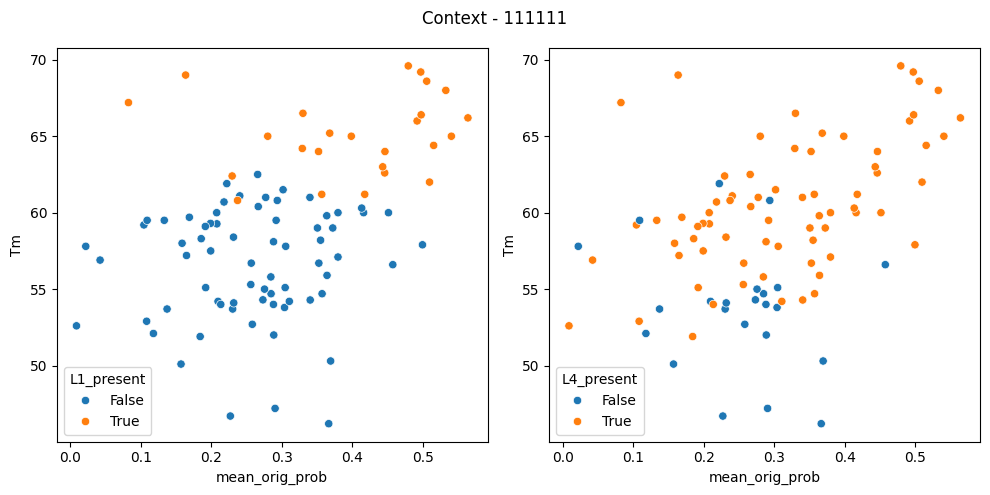

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


presence_loops = [1,4]
ncols = min(3, len(presence_loops))
nrows = max(1,int(len(presence_loops)/ncols))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10,5), squeeze = False)

for k, loop in enumerate(presence_loops):

    j = k % ncols 
    i = int(k / ncols)

    ancestors_table_presence_loop = all_anc_table.copy()
    ancestors_table_presence_loop[f"L{loop}_present"] = ancestors_table_presence_loop[f"orig_L{loop}"].apply(lambda x: True if x else False)
    sns.scatterplot(x = "mean_orig_prob", y = "Tm", data=ancestors_table_presence_loop, ax = axes[i][j], hue = f"L{loop}_present")
    
plt.suptitle(f'Context - {context_loops}')
plt.tight_layout()

# plt.savefig(f"./figures/loops_{context_loops}_Tm_presence_loop_1_4.png")

Text(0.1, 0.9, 'pearson_corr = 0.53')

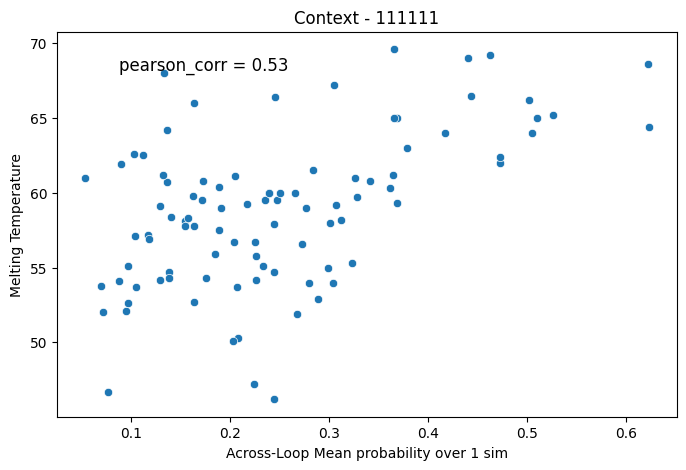

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib import rcParams

rcParams["figure.figsize"] = 8,5

all_anc_table_tm = all_anc_table.dropna(subset=["Tm"])

# plt.errorbar(all_anc_table_tm["mean_orig_prob_mean"], all_anc_table_tm["Tm"],
#                       xerr = all_anc_table_tm["mean_orig_prob_std"], fmt = "none", ecolor = "lightblue",  capsize = 5, zorder = 1)

sns.scatterplot(x="mean_orig_prob_mean", y = "Tm", data = all_anc_table_tm)
plt.xlabel("Across-Loop Mean probability over 1 sim")
plt.ylabel("Melting Temperature")
plt.title(f"Context - {context_loops}")

pearson_corr = pearsonr(x=all_anc_table_tm["mean_orig_prob_mean"], y = all_anc_table_tm["Tm"]).statistic
plt.annotate(f"pearson_corr = {pearson_corr:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig(f"./figures/across_fws_{context_loops}_Tm.png")

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

all_anc_table_tm = all_anc_table.dropna(subset=["Tm"])

sns.scatterplot(x="mean_orig_prob", y = "Tm", hue = "loops_present", data = all_anc_table_tm)
plt.xlabel("Mean probability across loops")
plt.ylabel("Melting Temperature")
plt.title(f"Context - {context_loops}")

pearson_corr = pearsonr(x=all_anc_table_tm["mean_orig_prob"], y = all_anc_table_tm["Tm"]).statistic
plt.annotate(f"pearson_corr = {pearson_corr:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig(f"./figures/loops_{context_loops}_Tm_loop_presence.png")


ValueError: Could not interpret value `loops_present` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
pearsonr(x=all_anc_table_tm["mean_orig_prob"], y = all_anc_table_tm["Tm"]).statistic

-0.45356899127745354

Text(0.1, 0.9, 'pearson_corr = 0.12')

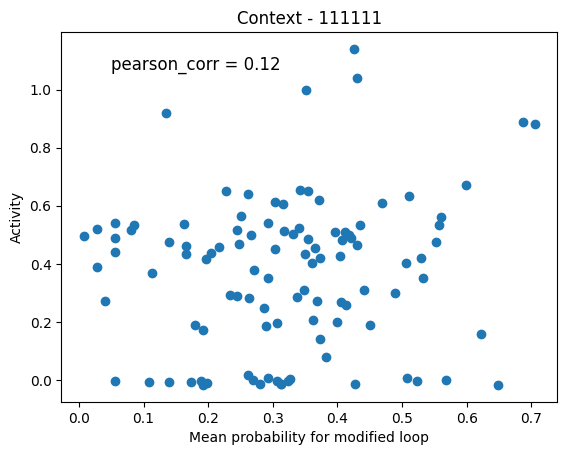

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

all_anc_table_activity = all_anc_table.dropna(subset=["chitinase (lysate)"])
plt.scatter(x=all_anc_table_activity["mean_orig_prob"], y = all_anc_table_activity["chitinase (lysate)"])

pearson_corr = pearsonr(x=all_anc_table_activity["mean_orig_prob"], y = all_anc_table_activity["chitinase (lysate)"]).statistic
plt.xlabel("Mean probability for modified loop")
plt.ylabel("Activity")
plt.title(f"Context - {context_loops}")
plt.annotate(f"pearson_corr = {pearson_corr:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig(f"./figures/loops_{context_loops}_activity_mod_loop.png")

In [ ]:
pearsonr(x=all_anc_table_activity["mean_orig_prob"], y = all_anc_table_activity["chitinase (lysate)"]).statistic

0.3757914014864632

### Logo Plots

In [ ]:
context_path = f"./contexts/loops_{context_loops}.fasta"
context_seqs_MSA = read_msa(context_path)

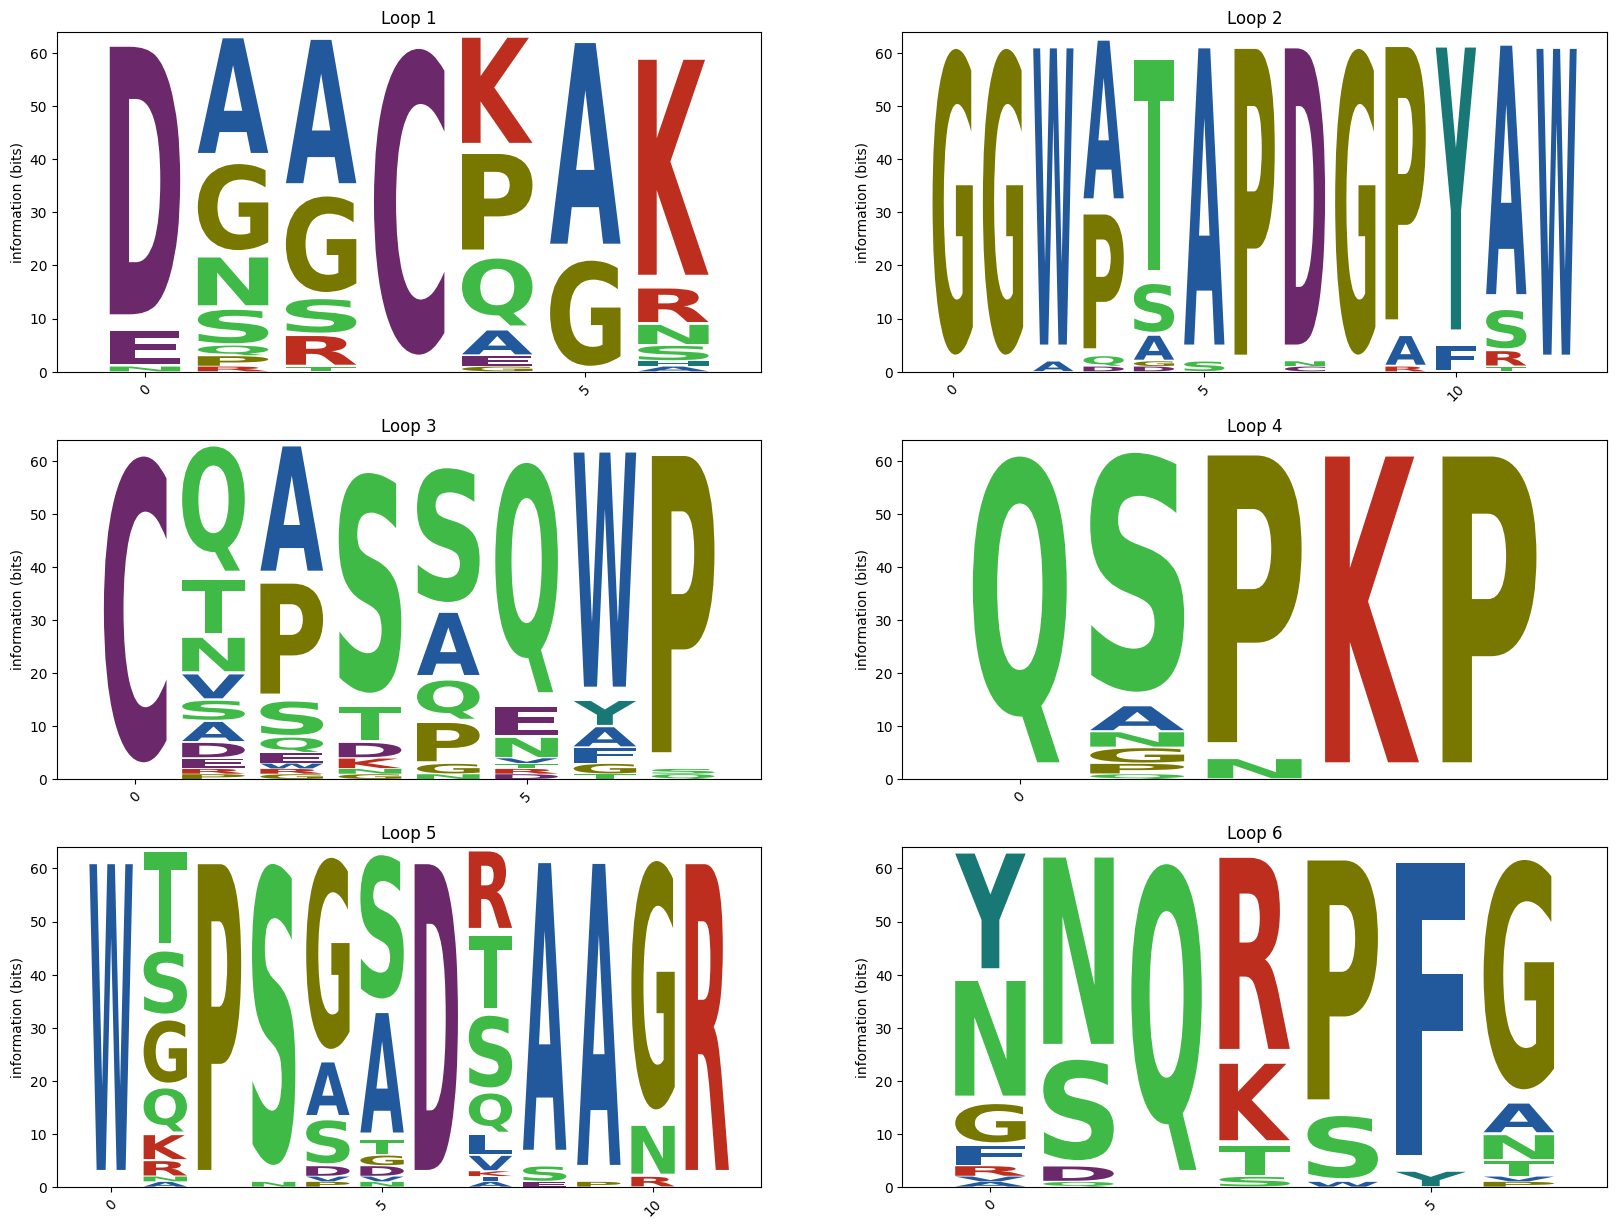

In [ ]:
import logomaker
from matplotlib import rcParams

nrows = 3
ncols = 2

Loop_lengths = [7,13, 8, 5, 12, 7]
Loop_start_points = [14, 64, 91, 156, 170, 231]

fig, axes  = plt.subplots(nrows= nrows, ncols = ncols, figsize = (20,15))

loop_ranges = [(14,20),(64,76),(91,98),(156,160),(170,181),(231,237)]

for k,loop in enumerate(loop_ranges):

    protmamba_context_df = logomaker.alignment_to_matrix([seq[1][loop[0]: loop[1] + 1] for seq in context_seqs_MSA])

    i = int(k/ncols)
    j = k % ncols

    # create Logo object
    protmamba_context_logo = logomaker.Logo(protmamba_context_df,
                            font_name='Stencil Std',
                            color_scheme='NajafabadiEtAl2017',
                            ax=axes[i][j],
                            vpad=.1,
                            width=.8,
                            figsize=(10,8))

    # style using Logo methods
    protmamba_context_logo.style_xticks(anchor=0, spacing=5, rotation=45)
    # protmamba_context_logo.highlight_position(p=4, color='gold', alpha=.5)
    # protmamba_context_logo.highlight_position(p=26, color='gold', alpha=.5)

    # style using Axes methods
    protmamba_context_logo.ax.set_ylabel('information (bits)')
    protmamba_context_logo.ax.set_xlim([-1, len(protmamba_context_df)])
    protmamba_context_logo.ax.set_title(f"Loop {k+1}")

plt.savefig(f"./figures/Context_{context_loops}_loops_logo.png")